In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [5]:
df = pd.read_csv(r"C:\Users\kesha\Downloads\AB_NYC_2019.csv")

In [6]:
print(f"Dataset Shape: {df.shape}")
print("\n--- Data Types ---")
print(df.dtypes)

Dataset Shape: (48895, 16)

--- Data Types ---
id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object


In [7]:
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate records: {duplicates}")


Number of duplicate records: 0


In [8]:
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_count, 'Percentage (%)': missing_percent})
print("\n--- Missing Values Summary ---")
print(missing_df[missing_df['Missing Count'] > 0])


--- Missing Values Summary ---
                   Missing Count  Percentage (%)
name                          16        0.032723
host_name                     21        0.042949
last_review                10052       20.558339
reviews_per_month          10052       20.558339


In [10]:
df['name'] = df['name'].fillna('Unknown Listing')
df['host_name'] = df['host_name'].fillna('Unknown Host')

In [12]:
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

In [14]:
df['last_review'] = df['last_review'].fillna('No Review')

print("\nMissing values after treatment:", df.isnull().sum().sum())


Missing values after treatment: 0


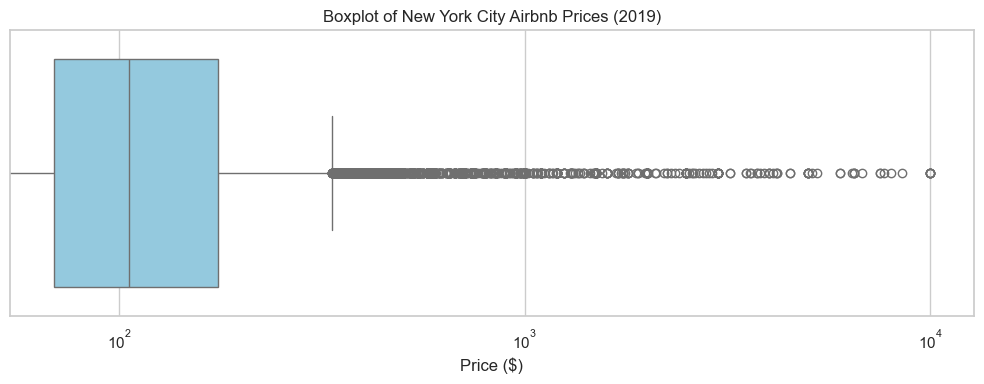

In [15]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['price'], color='skyblue')
plt.title('Boxplot of New York City Airbnb Prices (2019)')
plt.xlabel('Price ($)')
plt.xscale('log') # Applied log scale to make the massive range/long tail readable
plt.tight_layout()
plt.show()

In [16]:
def categorize_price(price):
    if price < 100:
        return 'Budget'
    elif 100 <= price <= 300:
        return 'Moderate'
    else:
        return 'High'

df['price_category'] = df['price'].apply(categorize_price)

In [17]:
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

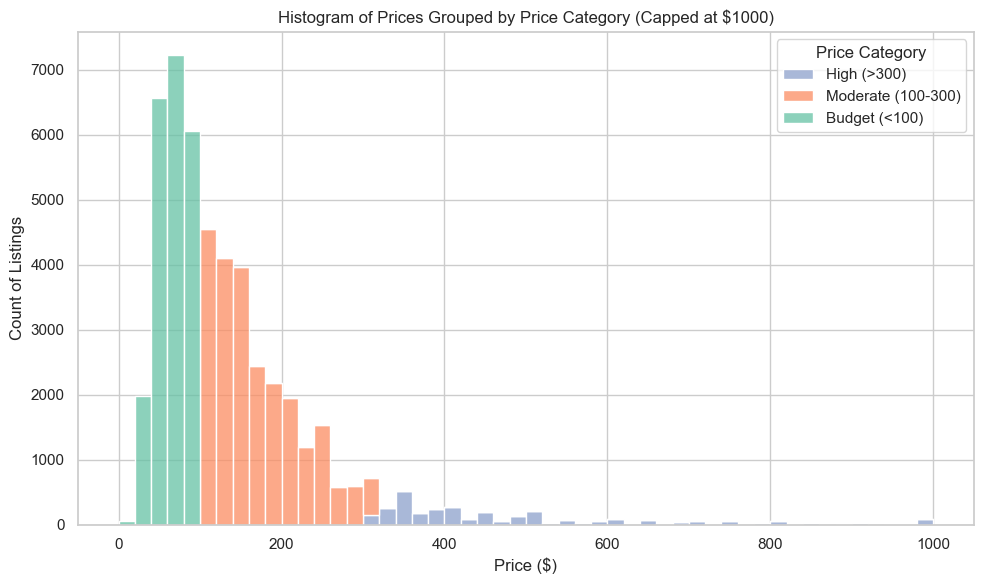

In [18]:
sns.histplot(data=df[df['price'] <= 1000], x='price', hue='price_category', 
             hue_order=['Budget', 'Moderate', 'High'], palette='Set2', multiple='stack', bins=50)
plt.title('Histogram of Prices Grouped by Price Category (Capped at $1000)')
plt.xlabel('Price ($)')
plt.ylabel('Count of Listings')
plt.legend(title='Price Category', labels=['High (>300)', 'Moderate (100-300)', 'Budget (<100)'])
plt.tight_layout()
plt.show()

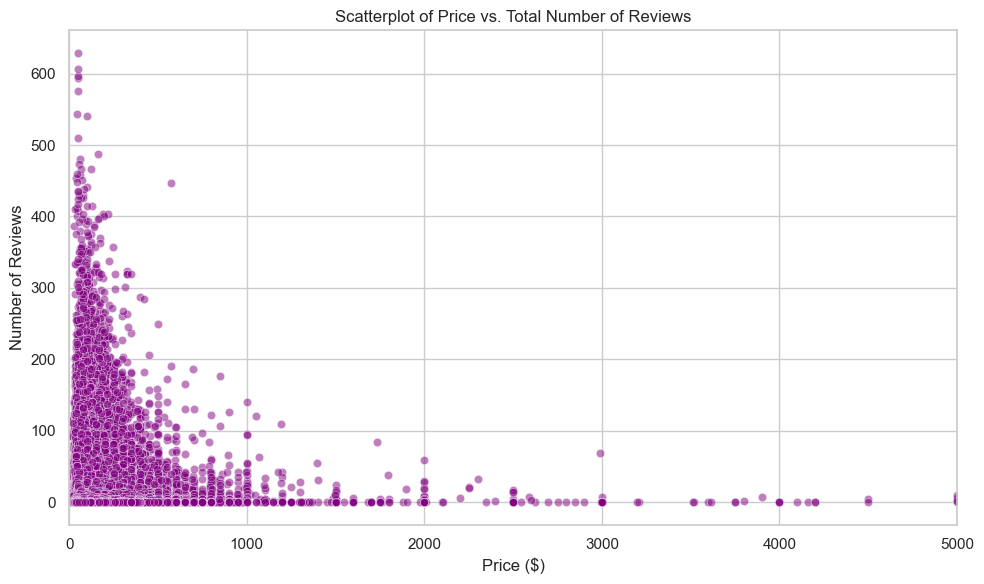

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='price', y='number_of_reviews', alpha=0.5, color='purple')
plt.title('Scatterplot of Price vs. Total Number of Reviews')
plt.xlabel('Price ($)')
plt.ylabel('Number of Reviews')
plt.xlim(0, 5000) # Capping X-axis to focus on the main data density
plt.tight_layout()
plt.show()

C:\Users\kesha\AppData\Local\Temp\ipykernel_42160\79460083.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_price_neighborhood, x='neighbourhood_group', y='price', palette='Blues_r')


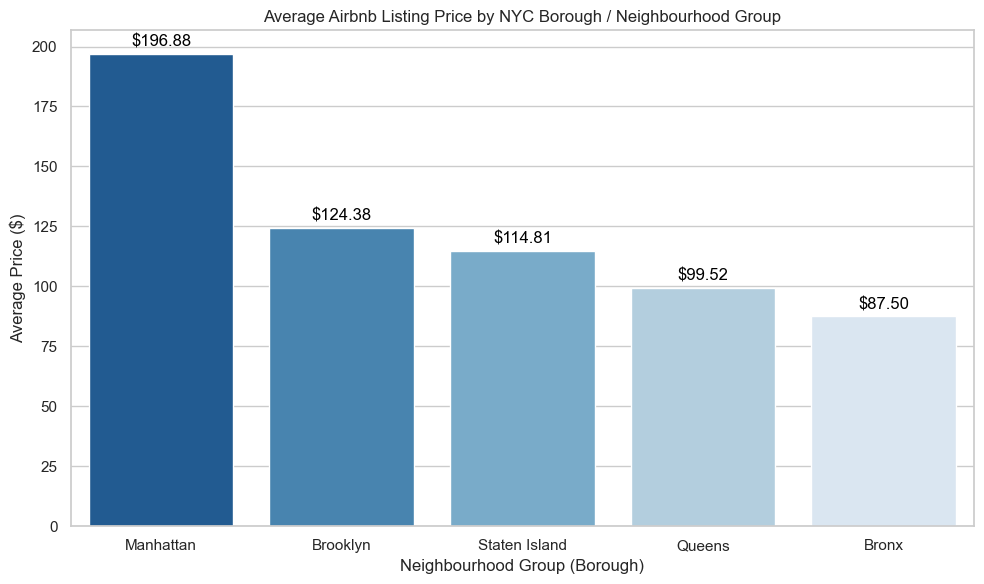

In [20]:
avg_price_neighborhood = df.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=avg_price_neighborhood, x='neighbourhood_group', y='price', palette='Blues_r')
plt.title('Average Airbnb Listing Price by NYC Borough / Neighbourhood Group')
plt.xlabel('Neighbourhood Group (Borough)')
plt.ylabel('Average Price ($)')
for index, row in avg_price_neighborhood.iterrows():
    plt.text(index, row['price'] + 3, f"${row['price']:.2f}", color='black', ha="center")
plt.tight_layout()
plt.show()

C:\Users\kesha\AppData\Local\Temp\ipykernel_42160\237639190.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_avail_room, x='room_type', y='availability_365', palette='Greens_r')


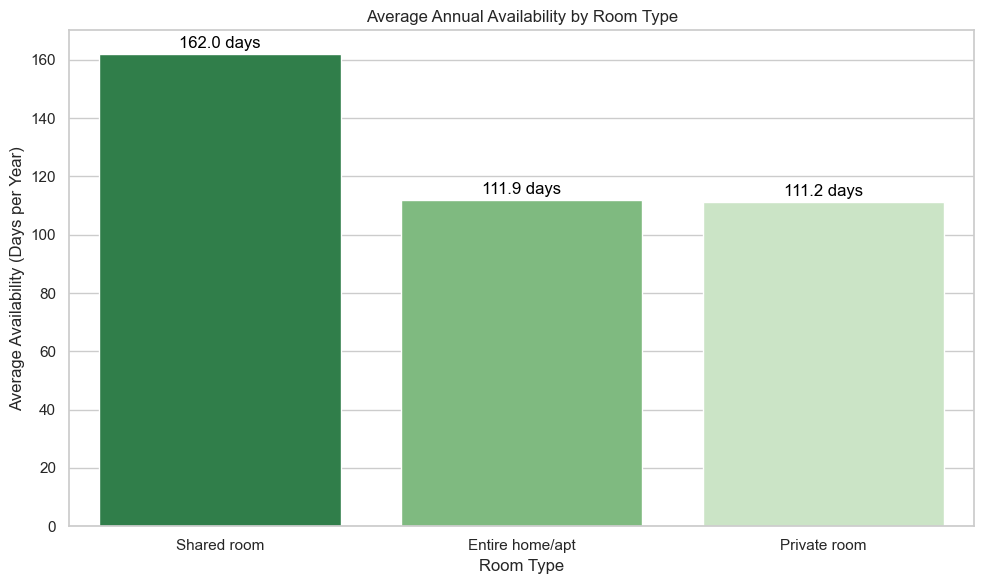

In [21]:
avg_avail_room = df.groupby('room_type')['availability_365'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=avg_avail_room, x='room_type', y='availability_365', palette='Greens_r')
plt.title('Average Annual Availability by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Average Availability (Days per Year)')
for index, row in avg_avail_room.iterrows():
    plt.text(index, row['availability_365'] + 2, f"{row['availability_365']:.1f} days", color='black', ha="center")
plt.tight_layout()
plt.show()

In [22]:
df_titanic = pd.read_csv(r"C:\Users\kesha\Downloads\train.csv")

In [23]:
print("--- Dataset Shape ---")
print(f"Rows: {df_titanic.shape[0]}, Columns: {df_titanic.shape[1]}")

print("\n--- Column Names & Data Types ---")
print(df_titanic.dtypes)

--- Dataset Shape ---
Rows: 891, Columns: 12

--- Column Names & Data Types ---
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [24]:
age_mean = df_titanic['Age'].mean()
age_median = df_titanic['Age'].median()
age_mode = df_titanic['Age'].mode()[0]

In [25]:
print("\n--- Age Central Tendency Statistics ---")
print(f"Mean Age:   {age_mean:.2f}")
print(f"Median Age: {age_median:.2f}")
print(f"Mode Age:   {age_mode:.2f}")


--- Age Central Tendency Statistics ---
Mean Age:   29.70
Median Age: 28.00
Mode Age:   24.00


In [26]:
fare_std = df_titanic['Fare']. Orca = df_titanic['Fare'].std()
print(f"\nStandard Deviation of Fare: {fare_std:.4f}")


Standard Deviation of Fare: 49.6934


In [27]:
missing_count = df_titanic.isnull().sum()
missing_percent = (df_titanic.isnull().sum() / len(df_titanic)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_count, 'Percentage (%)': missing_percent})
print("\n--- Missing Values Summary ---")
print(missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))


--- Missing Values Summary ---
          Missing Count  Percentage (%)
Cabin               687       77.104377
Age                 177       19.865320
Embarked              2        0.224467


In [28]:
print("\n--- Grouped Analysis Results ---")


--- Grouped Analysis Results ---


In [29]:
fare_by_survival = df_titanic.groupby('Survived')['Fare'].mean()
print("\nAverage Fare by Survival Status (0 = Deceased, 1 = Survived):")
print(fare_by_survival.to_string())


Average Fare by Survival Status (0 = Deceased, 1 = Survived):
Survived
0    22.117887
1    48.395408


In [30]:
age_by_pclass = df_titanic.groupby('Pclass')['Age'].mean()
print("\nAverage Age by Passenger Class (Pclass):")
print(age_by_pclass.to_string())


Average Age by Passenger Class (Pclass):
Pclass
1    38.233441
2    29.877630
3    25.140620


In [31]:
survival_by_sex = df_titanic.groupby('Sex')['Survived'].mean()
print("\nSurvival Rate by Sex:")
print(survival_by_sex.to_string())


Survival Rate by Sex:
Sex
female    0.742038
male      0.188908


C:\Users\kesha\AppData\Local\Temp\ipykernel_42160\2436198583.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_titanic, x='Survived', y='Fare', palette='Set1')


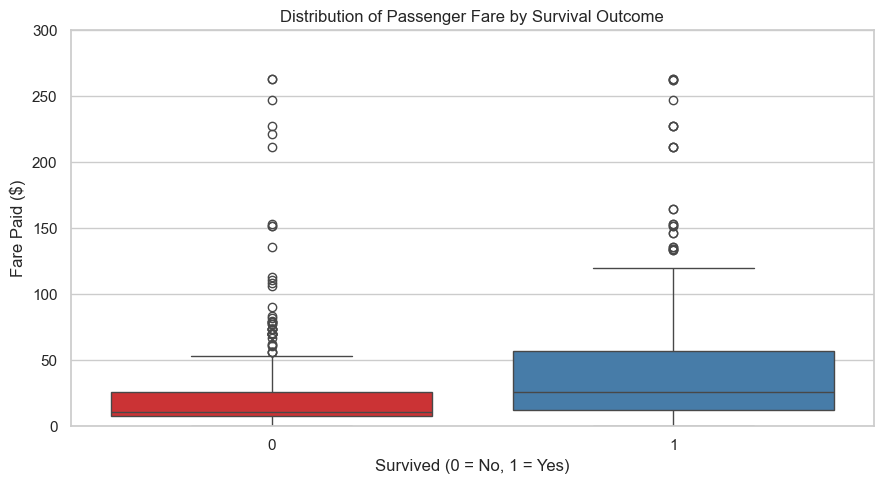

In [32]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df_titanic, x='Survived', y='Fare', palette='Set1')
plt.title('Distribution of Passenger Fare by Survival Outcome')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Fare Paid ($)')
plt.ylim(0, 300) # Capping y-axis limit to visualize the boxes clearly past extreme outliers
plt.tight_layout()
plt.show()

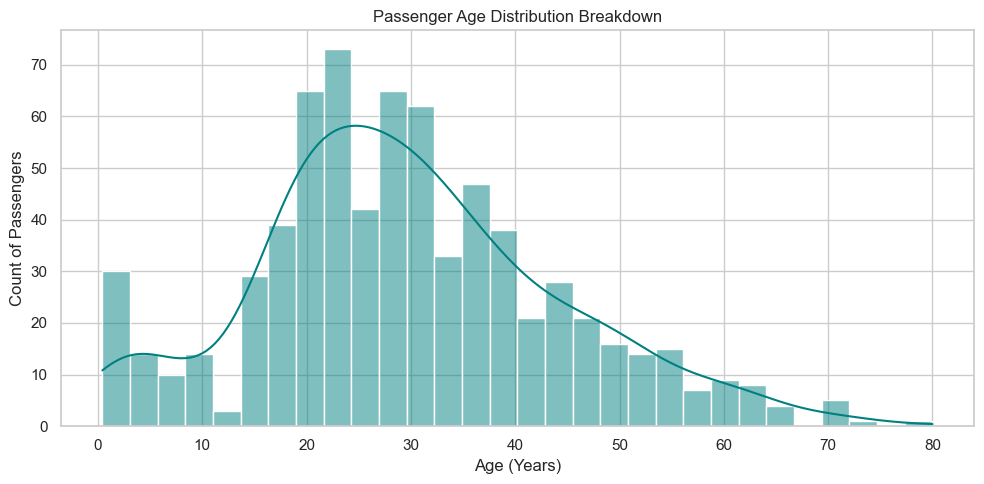

In [33]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df_titanic, x='Age', kde=True, bins=30, color='teal')
plt.title('Passenger Age Distribution Breakdown')
plt.xlabel('Age (Years)')
plt.ylabel('Count of Passengers')
plt.tight_layout()
plt.show()

C:\Users\kesha\AppData\Local\Temp\ipykernel_42160\3801846826.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_titanic, x='Pclass', y='Age', palette='Set2')


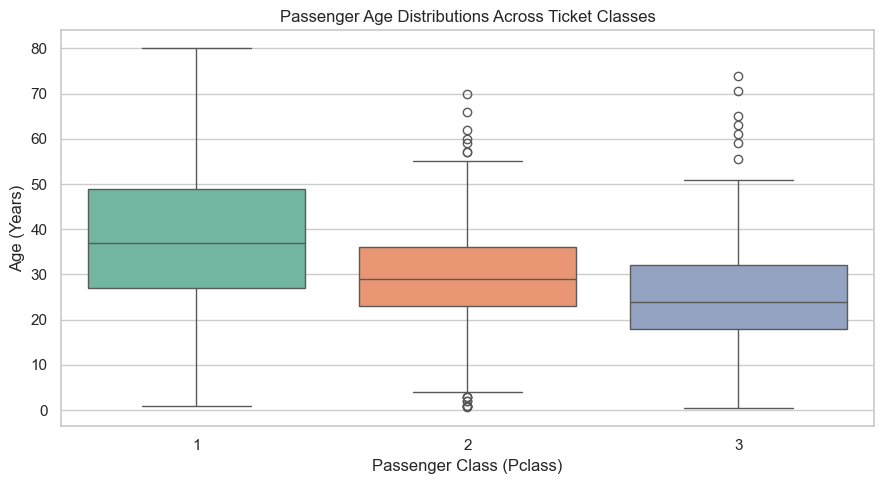

In [34]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df_titanic, x='Pclass', y='Age', palette='Set2')
plt.title('Passenger Age Distributions Across Ticket Classes')
plt.xlabel('Passenger Class (Pclass)')
plt.ylabel('Age (Years)')
plt.tight_layout()
plt.show()

In [35]:
print("--- Survival Rate by Passenger Class (Pclass) ---")
pclass_survival = df_titanic.groupby('Pclass')['Survived'].mean()
print(pclass_survival.to_string())

--- Survival Rate by Passenger Class (Pclass) ---
Pclass
1    0.629630
2    0.472826
3    0.242363


In [36]:
print("\n--- Survival Rate by Embarkation Point (Embarked) ---")
embarked_survival = df_titanic.groupby('Embarked')['Survived'].mean()
print(embarked_survival.to_string())


--- Survival Rate by Embarkation Point (Embarked) ---
Embarked
C    0.553571
Q    0.389610
S    0.336957


C:\Users\kesha\AppData\Local\Temp\ipykernel_42160\3426215289.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_titanic, x='Sex', y='Survived', palette='muted', errorbar=None)


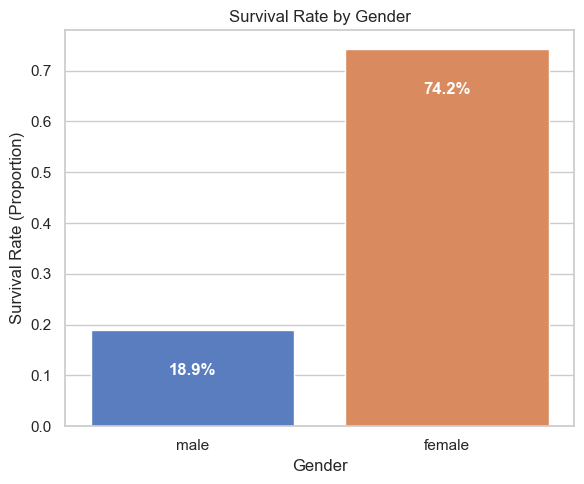

In [37]:
plt.figure(figsize=(6, 5))
sns.barplot(data=df_titanic, x='Sex', y='Survived', palette='muted', errorbar=None)
plt.title('Survival Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Survival Rate (Proportion)')
# Add data labels
for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_height()*100:.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() - 0.08),
                ha='center', va='center', color='white', fontweight='bold', xytext=(0, 0), textcoords='offset points')
plt.tight_layout()
plt.show()

C:\Users\kesha\AppData\Local\Temp\ipykernel_42160\3515778247.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_titanic, x='Pclass', y='Survived', palette='deep', errorbar=None)


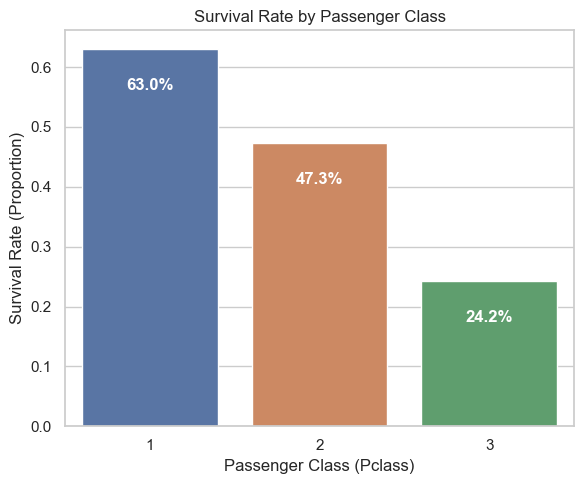

In [38]:
plt.figure(figsize=(6, 5))
sns.barplot(data=df_titanic, x='Pclass', y='Survived', palette='deep', errorbar=None)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class (Pclass)')
plt.ylabel('Survival Rate (Proportion)')
for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_height()*100:.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() - 0.06),
                ha='center', va='center', color='white', fontweight='bold', xytext=(0, 0), textcoords='offset points')
plt.tight_layout()
plt.show()

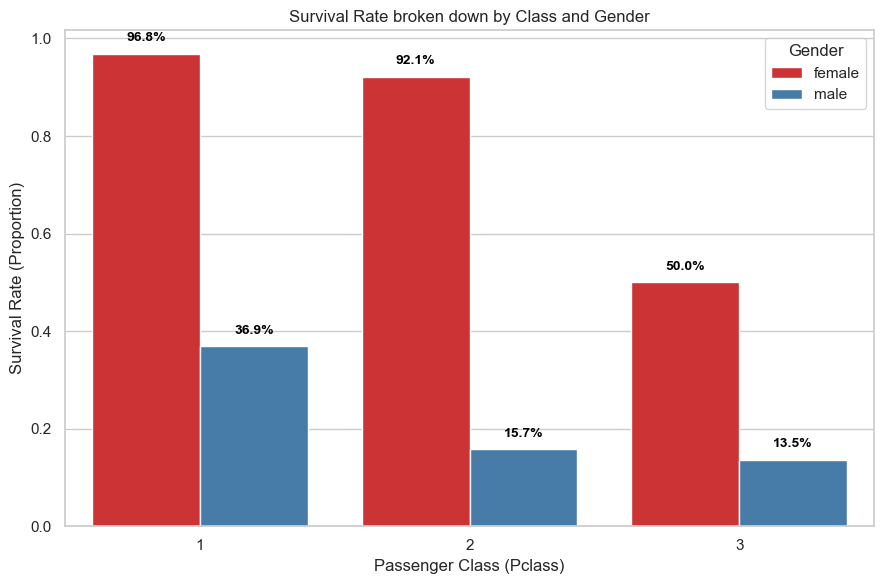

In [39]:
plt.figure(figsize=(9, 6))
sns.barplot(data=df_titanic, x='Pclass', y='Survived', hue='Sex', palette='Set1', errorbar=None)
plt.title('Survival Rate broken down by Class and Gender')
plt.xlabel('Passenger Class (Pclass)')
plt.ylabel('Survival Rate (Proportion)')
plt.legend(title='Gender')
# Add data labels dynamically
for p in plt.gca().patches:
    height = p.get_height()
    if height > 0: # Avoid labeling empty bars if any
        plt.gca().annotate(f"{height*100:.1f}%", (p.get_x() + p.get_width() / 2., height + 0.02),
                    ha='center', va='bottom', color='black', fontsize=10, fontweight='semibold')
plt.tight_layout()
plt.show()

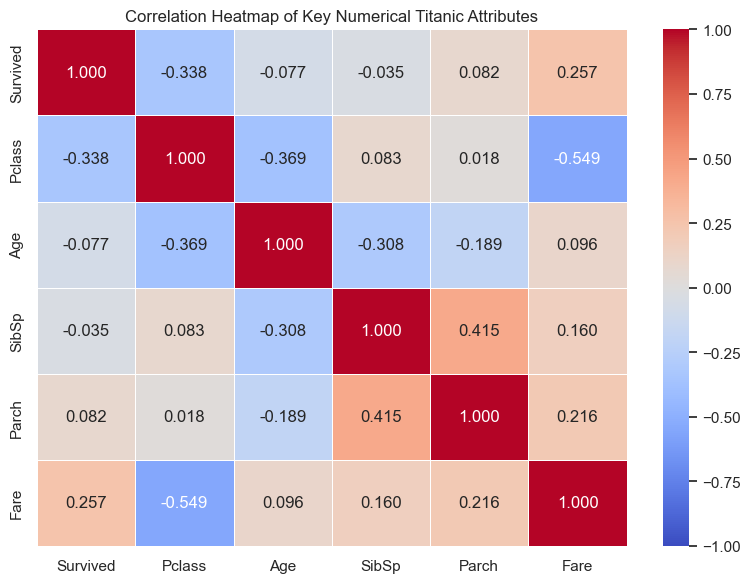

In [40]:
relevant_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
df_numeric = df_titanic[relevant_cols]

# Compute correlation matrix
corr_matrix = df_numeric.corr()

# Graph 4: Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Key Numerical Titanic Attributes')
plt.tight_layout()
plt.show()

In [55]:
df = pd.read_csv(r"C:\Users\kesha\Downloads\Global_Superstore2.csv", encoding='ISO-8859-1')

In [56]:
print("--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n--- Column Names and Data Types ---")
print(df.dtypes)

--- Dataset Shape ---
Rows: 51290, Columns: 24

--- Column Names and Data Types ---
Row ID              int64
Order ID           object
Order Date         object
Ship Date          object
Ship Mode          object
Customer ID        object
Customer Name      object
Segment            object
City               object
State              object
Country            object
Postal Code       float64
Market             object
Region             object
Product ID         object
Category           object
Sub-Category       object
Product Name       object
Sales             float64
Quantity            int64
Discount          float64
Profit            float64
Shipping Cost     float64
Order Priority     object
dtype: object


In [57]:
print("\n--- Missing Values Summary ---")
missing_counts = df.isnull().sum()
print(missing_counts[missing_counts > 0])


--- Missing Values Summary ---
Postal Code    41296
dtype: int64


In [58]:
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate records: {duplicates}")


Number of duplicate records: 0


In [59]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d-%m-%Y')

print("\n--- Data Types After Conversion ---")
print(df[['Order Date', 'Ship Date']].dtypes)


--- Data Types After Conversion ---
Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [60]:
df['Year'] = df['Order Date'].dt.year

In [61]:
sales_by_region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print("\n--- Total Sales by Region ---")
print(sales_by_region.map('${:,.2f}'.format))


--- Total Sales by Region ---
Region
Central           $2,822,302.52
South             $1,600,907.04
North             $1,248,165.60
Oceania           $1,100,184.61
Southeast Asia      $884,423.17
North Asia          $848,309.78
EMEA                $806,161.31
Africa              $783,773.21
Central Asia        $752,826.57
West                $725,457.82
East                $678,781.24
Caribbean           $324,280.86
Canada               $66,928.17
Name: Sales, dtype: object


In [62]:
sales_by_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print("\n--- Total Sales by Category ---")
print(sales_by_category.map('${:,.2f}'.format))


--- Total Sales by Category ---
Category
Technology         $4,744,557.50
Furniture          $4,110,874.19
Office Supplies    $3,787,070.23
Name: Sales, dtype: object


In [63]:
profit_by_region = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
print("\n--- Total Profit by Region ---")
print(profit_by_region.map('${:,.2f}'.format))


--- Total Profit by Region ---
Region
Central           $311,403.98
North             $194,597.95
North Asia        $165,578.42
South             $140,355.77
Central Asia      $132,480.19
Oceania           $120,089.11
West              $108,418.45
East               $91,522.78
Africa             $88,871.63
EMEA               $43,897.97
Caribbean          $34,571.32
Southeast Asia     $17,852.33
Canada             $17,817.39
Name: Profit, dtype: object


In [64]:
sales_by_year = df.groupby('Year')['Sales'].sum()
print("\n--- Total Sales by Year ---")
print(sales_by_year.map('${:,.2f}'.format))


--- Total Sales by Year ---
Year
2011    $2,259,450.90
2012    $2,677,438.69
2013    $3,405,746.45
2014    $4,299,865.87
Name: Sales, dtype: object


In [65]:
profit_region_cat = df.groupby(['Region', 'Category'])['Profit'].sum().reset_index()
most_profitable = profit_region_cat.sort_values(by='Profit', ascending=False).iloc[0]
least_profitable = profit_region_cat.sort_values(by='Profit', ascending=True).iloc[0]

print("\n--- Multi-level Groupby (Region & Category) ---")
print(f"Most Profitable: {most_profitable['Region']} - {most_profitable['Category']} (${most_profitable['Profit']:,.2f})")
print(f"Least Profitable: {least_profitable['Region']} - {least_profitable['Category']} (${least_profitable['Profit']:,.2f})")


--- Multi-level Groupby (Region & Category) ---
Most Profitable: Central - Technology ($135,538.42)
Least Profitable: Southeast Asia - Furniture ($-7,269.77)


In [71]:
sales_by_region_df = sales_by_region.reset_index()

fig1, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=sales_by_region_df,
    x='Region',
    y='Sales',
    hue='Region',          
    palette='viridis',
    ax=ax1,
    legend=False           
)

ax1.set_title('Total Sales by Geographic Region')
ax1.set_xlabel('Region')
ax1.set_ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('sales_by_region.png')
plt.close()

In [73]:
profit_by_cat_df = df.groupby('Category')['Profit'].sum().sort_values(ascending=False).reset_index()

fig2, ax2 = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=profit_by_cat_df,
    x='Category',
    y='Profit',
    hue='Category',     
    palette='magma',
    ax=ax2,
    legend=False        
)

ax2.set_title('Total Profit by Product Category')
ax2.set_xlabel('Category')
ax2.set_ylabel('Total Profit ($)')
plt.tight_layout()
plt.savefig('profit_by_category.png')
plt.close()

In [75]:
sales_by_year_df = sales_by_year.reset_index()

fig3, ax3 = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=sales_by_year_df,
    x='Year',
    y='Sales',
    hue='Year',        
    palette='Blues',
    ax=ax3,
    legend=False      
)

ax3.set_title('Total Sales Trend Over Time (2011-2014)')
ax3.set_xlabel('Year')
ax3.set_ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('sales_by_year.png')
plt.close()

In [77]:
profit_by_subcat_df = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False).reset_index()

fig4, ax4 = plt.subplots(figsize=(10, 8))

sns.barplot(
    data=profit_by_subcat_df,
    y='Sub-Category',
    x='Profit',
    hue='Sub-Category',   # ✅ fix
    palette='coolwarm',
    ax=ax4,
    legend=False          # clean output
)

ax4.set_title('Total Profit Breakdown by Product Sub-Category')
ax4.set_xlabel('Total Profit ($)')
ax4.set_ylabel('Sub-Category')

plt.tight_layout()
plt.savefig('profit_by_subcat.png')
plt.close()

print("\nAll visualizations have been successfully generated and saved.")


All visualizations have been successfully generated and saved.
